# Análisis Exploratorio de Datos (EDA)


En este notebook realizamos una exploración profunda de los activos del IBEX 35 para validar nuestras hipótesis de inversión mediante visualizaciones profesionales.


1. **Rendimiento Sectorial (H1):** ¿Existe realmente dispersión entre sectores?
2. **Binomio Riesgo-Retorno:** ¿Quién ofrece la mejor eficiencia?
3. **Riesgo Específico (H2):** El comportamiento del sector bancario.
4. **Contexto Global:** La relación entre el IBEX y el "Índice del Miedo" (VIX).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración graficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Carga de Datos
df_precios = pd.read_csv('../Datos/ibex35_precios.csv', index_col='Date', parse_dates=True)
df_comp = pd.read_csv('../Datos/ibex35_componentes.csv')

# 2. Cálculo de Retornos
df_retornos = df_precios.pct_change().dropna()

print("✅ Entorno preparado. Datos cargados:")
print(f"- Periodo: {df_precios.index.min().date()} a {df_precios.index.max().date()}")
print(f"- Activos: {df_precios.shape[1]} (IBEX 35 + Benchmarks)")

✅ Entorno preparado. Datos cargados:
- Periodo: 2021-03-05 a 2026-03-05
- Activos: 38 (IBEX 35 + Benchmarks)


## 1. El Impacto de la Selección: Rendimiento Medio por Sector (H1)
**Objetivo:** Evaluar la dispersión de retornos entre los distintos sectores económicos. Este análisis es fundamental para validar la **Hipótesis 1 (H1)**: el mercado no es un bloque homogéneo y la selección sectorial es la clave del rendimiento.

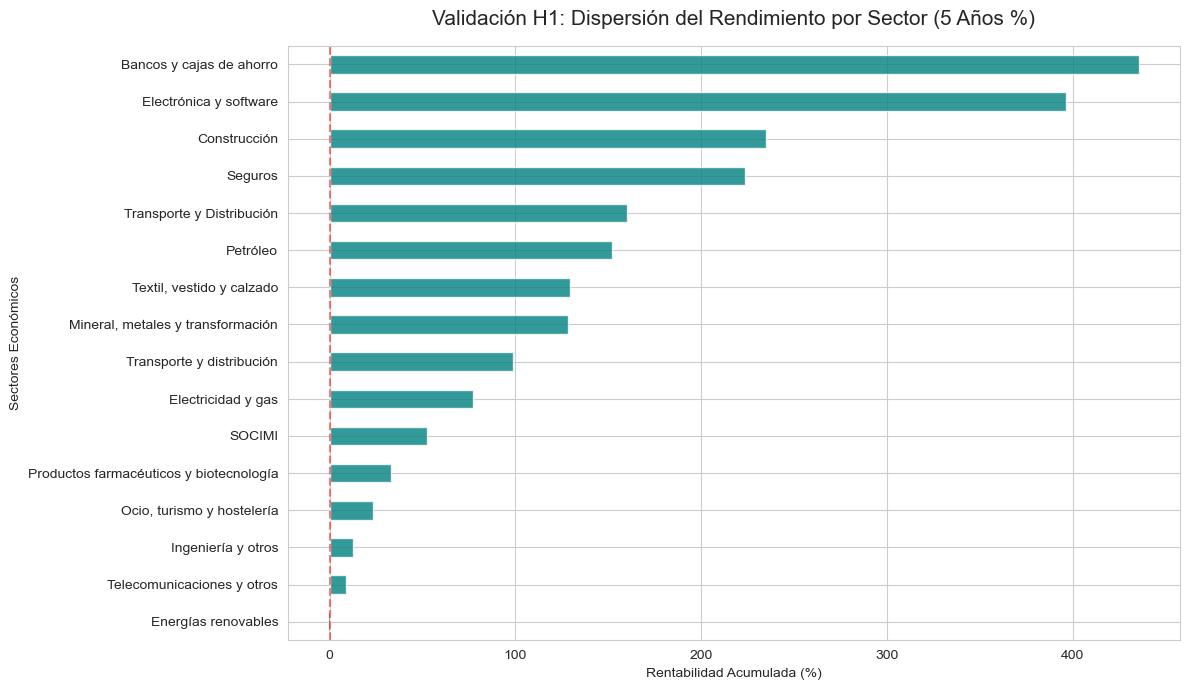

In [8]:
# Calculamos el retorno total acumulado en 5 años (%)
retorno_total = (df_precios.iloc[-1] / df_precios.iloc[0] - 1) * 100

# Mapeamos con el catálogo de sectores
df_sectores = df_comp.set_index('ticker_yahoo')
df_sectores['retorno_total'] = retorno_total

# Agrupamos por sector
rendimiento_sectorial = df_sectores.groupby('sector')['retorno_total'].mean().sort_values()

# Visualización de Rendimiento por Industrias
plt.figure(figsize=(12, 7))
rendimiento_sectorial.plot(kind='barh', color='teal', alpha=0.8)
plt.title('Validación H1: Dispersión del Rendimiento por Sector (5 Años %)', fontsize=15, pad=15)
plt.xlabel('Rentabilidad Acumulada (%)')
plt.ylabel('Sectores Económicos')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Conclusiones

- Validación de H1: Existe una brecha de más de 400 puntos porcentuales entre el sector con mas retornos (Bancos) y el con menos retornos (Renovables). Esto nos confirma que una estrategia de inversión pasiva ("comprar el índice") habría diluido enormemente los retornos generados por los sectores ganadores en estos 5 años.

- El Motor del IBEX: El sector bancario y de cajas de ahorro ha sido el motor absoluto del mercado español. Esto le da un valor estratégico a nuestra Hipótesis 2: si la rentabilidad del índice depende tanto de un solo sector, entender su correlación interna es vital para no concentrar todo el riesgo de nuestra cartera.

- El sector de Renovables es el único sector en terreno negativo en el acumulado. Como analistas, esto nos obliga a advertir que "temática popular" no siempre equivale a "rentabilidad realizada". Esta es una de nuestras conclusiones más valiosas para el informe.

- Sectores como Electrónica y Software o Construcción han tenido un desempeño extraordinario (superando el 200%). Esto nos sugiere que hay oportunidades de alto rendimiento fuera de los sospechosos habituales que nuestro simulador debería ser capaz de detectar.

## 2. Evaluación del Binomio Riesgo-Retorno
**Objetivo:** Determinación de los activos que han ofrecido una mayor rentabilidad por cada unidad de volatilidad (riesgo) asumida. Buscamos identificar las cotizadas con mejor desempeño relativo y eficiencia en la generación de retornos frente a su exposición al mercado.

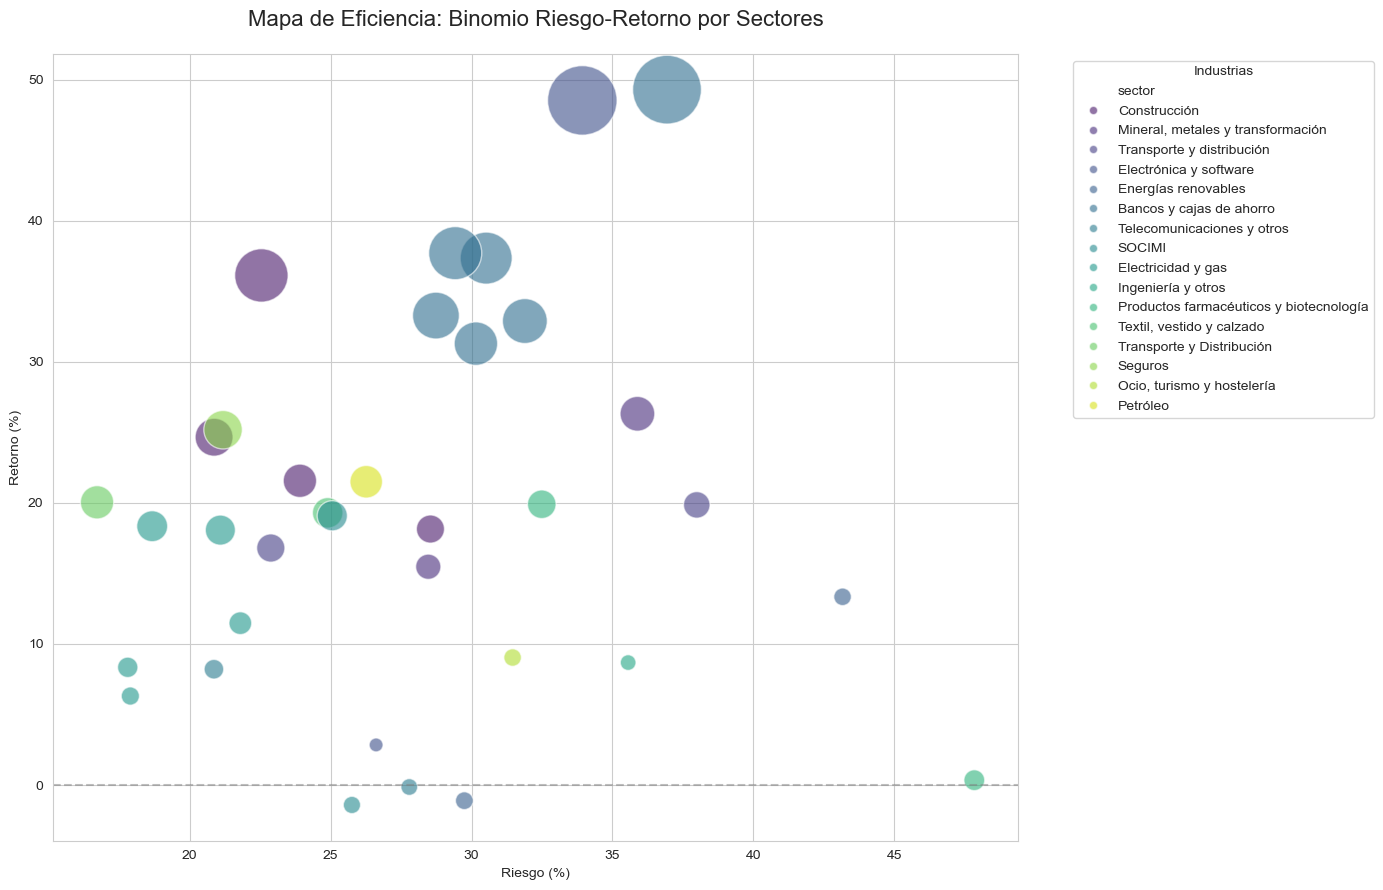

In [9]:

# Métricas anualizadas
retorno_anual = df_retornos.mean() * 252 * 100
vol_anual = df_retornos.std() * np.sqrt(252) * 100

# Filtramos outliers de escala (VIX) para una mejor visualización
activos_plot = [t for t in retorno_anual.index if t != '^VIX']

df_plot = pd.DataFrame({
    'Retorno (%)': retorno_anual[activos_plot],
    'Riesgo (%)': vol_anual[activos_plot]
})

# Integración sectorial
df_plot = df_plot.merge(df_comp[['ticker_yahoo', 'sector']], left_index=True, right_on='ticker_yahoo')


# Usamos ticker_yahoo que ya existe en df_plot gracias al merge
df_plot['size'] = df_plot['ticker_yahoo'].map(retorno_total).abs() * 20

# Creación del Mapa de Eficiencia
plt.figure(figsize=(14, 9))
ax = sns.scatterplot(data=df_plot, x='Riesgo (%)', y='Retorno (%)', size='size', sizes=(100, 2500),hue='sector',palette='viridis', alpha=0.6) 
h, l = ax.get_legend_handles_labels()
if 'size' in l:
    h, l = h[:l.index('size')], l[:l.index('size')]

# Etiquetamos Benchmarks de referencia
for i in range(df_plot.shape[0]):
    row = df_plot.iloc[i]
    if row['ticker_yahoo'] in ['^IBEX', 'GC=F']:
        plt.text(row['Riesgo (%)']+ 1.2, row['Retorno (%)'], row['ticker_yahoo'], 
                 fontsize=11, fontweight='bold', color='darkred')

plt.title('Mapa de Eficiencia: Binomio Riesgo-Retorno por Sectores', fontsize=16, pad=20)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend(h, l, bbox_to_anchor=(1.05, 1), loc='upper left', title='Industrias')
plt.tight_layout()
plt.show()

## Conclusiones: Eficiencia de Activos

- Lideres en valor: Los sectores de Banca y Tecnología dominan el mapa; son los únicos capaces de combinar retornos anualizados superiores al 30% con volúmenes de ganancia acumulada.
- Activos de Equilibrio: Existe una masa de activos en el rango del 15-25% de riesgo que garantizan estabilidad y liquidez a la cartera, aunque con una capacidad de crecimiento más limitada.
- Ineficiencia Estructural: Las Energías Renovables representan la volatilidad más alta del índice frente a los retornos totales más bajos del periodo.
- Umbral de Riesgo: La generación de riqueza real se optimiza en el entorno del 30% de riesgo; superar este nivel no ha resultado en mayores beneficios, sino en una ineficiencia sistémica.

## 3. Análisis de Correlación Dinámica (H2)
**Objetivo:** Investigar la estabilidad temporal de la correlación entre los referentes del sector bancario. Validamos la **Hipótesis 2 (H2)**: comprar múltiples activos del mismo sector no garantiza diversificación debido a su alto co-movimiento estructural.

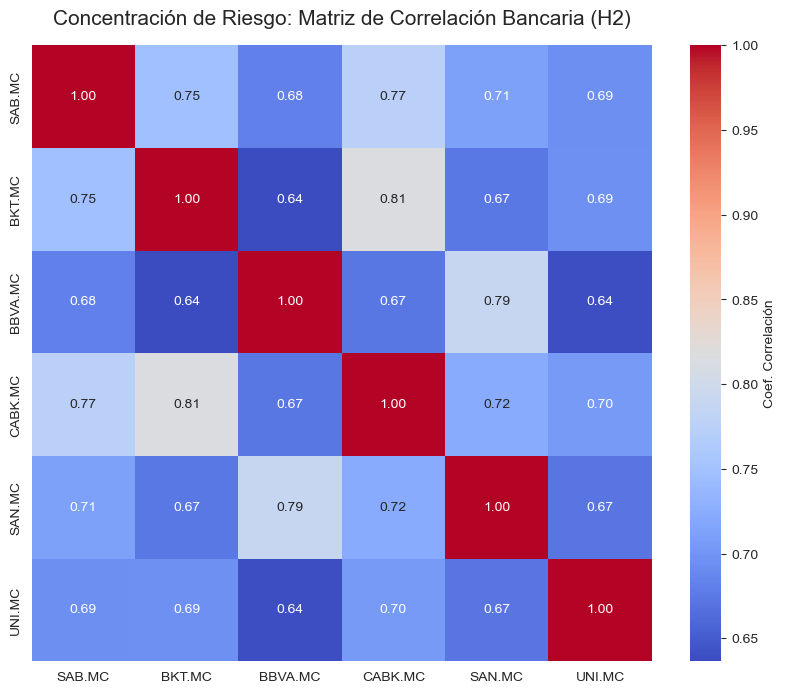

In [10]:
# Filtramos activos del sector bancario
bancos = df_comp[df_comp['sector'].str.contains('Bancos', na=False)]['ticker_yahoo'].tolist()

# 3.1. Matriz de Correlación Estática
plt.figure(figsize=(10, 8))
sns.heatmap(df_retornos[bancos].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Coef. Correlación'})
plt.title('Concentración de Riesgo: Matriz de Correlación Bancaria (H2)', fontsize=15, pad=15)
plt.show()



## Conclusiones: Matriz de Correlación Bancaria (Validación H2)


- Correlación Sistémica Alta: Casi todos los pares de bancos presentan una correlación superior al 0.65, con picos del 0.81 (como entre Bankinter y CaixaBank). Esto nos confirma que el sector bancario español se mueve "en bloque". Para un inversor, esto significa que comprar 4 bancos distintos no es diversificar, es triplicar la apuesta a una misma carta.

- La correlación entre los dos gigantes (SAN y BBVA) es de 0.79. Es una de las más altas y estables. Esto sugiere que sus modelos de negocio, a pesar de su diversificación internacional, responden de forma casi idéntica a los estímulos del mercado español.

- Concentración de Riesgo: El mapa de calor indica que no hay "refugios" dentro del sector bancario. Cuando el sector sufre por tipos de interés o noticias macro, el impacto es transversal. 

- Implicación para el Simulador: Esta matriz es la prueba de que el usuario de nuestro simulador necesita sectores des-correlacionados (como Tech o Construcción) para equilibrar el peso masivo y sincronizado de la banca en el IBEX 35.

## 4. Análisis de Sensibilidad: VIX vs. Volatilidad del IBEX 35
**Objetivo:** Evaluar la convergencia entre el sentimiento de riesgo global (VIX) y los periodos de alta volatilidad del mercado español. Este cierre contextualiza los resultados previos bajo un marco macroeconómico.

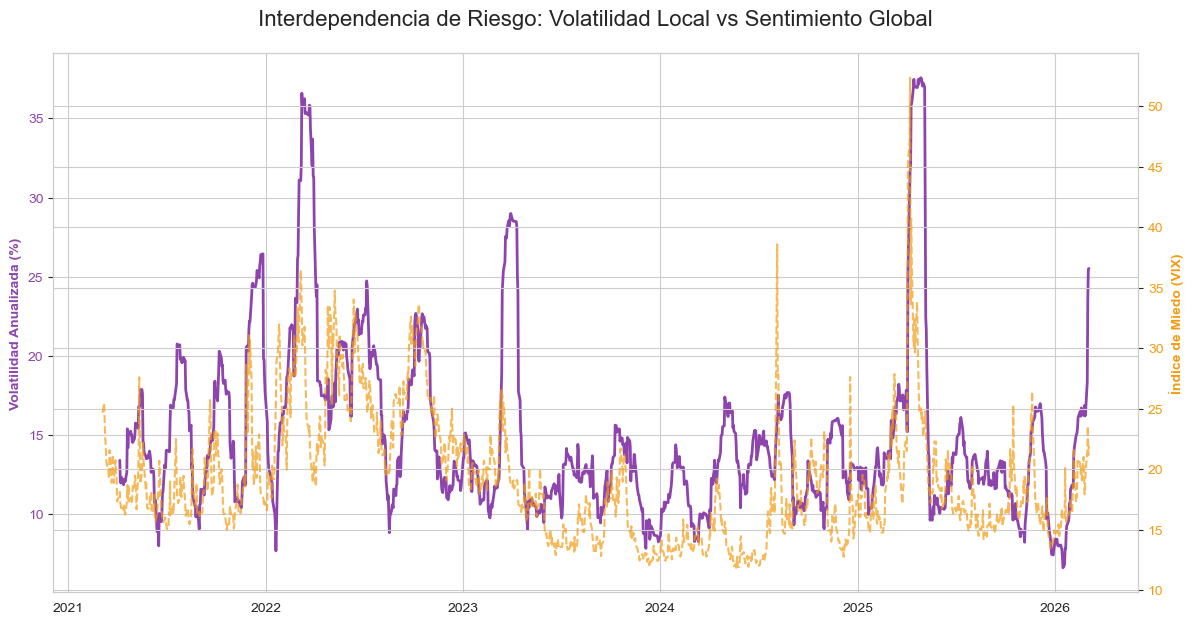

In [11]:
# Volatilidad rodante del IBEX 35 (anualizada)
vol_ibex = df_retornos['^IBEX'].rolling(window=21).std() * np.sqrt(252) * 100

# Gráfica de Doble Eje (Riesgo Local vs Miedo Global)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Volatilidad IBEX
ax1.plot(vol_ibex, color='#8E44AD', lw=2, label='Volatilidad Realizada IBEX 35')
ax1.set_ylabel('Volatilidad Anualizada (%)', color='#8E44AD', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#8E44AD')

# Índice VIX
ax2 = ax1.twinx()
ax2.plot(df_precios['^VIX'], color='#F39C12', linestyle='--', alpha=0.7, label='Nivel del VIX')
ax2.set_ylabel('Índice de Miedo (VIX)', color='#F39C12', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#F39C12')

plt.title('Interdependencia de Riesgo: Volatilidad Local vs Sentimiento Global', fontsize=16, pad=20)
plt.show()

## Conclusiones VIX vs. Volatilidad IBEX

- Existe una correlación visual directa y estrecha entre el VIX (naranja) y la volatilidad del IBEX 35 (púrpura). Cuando el VIX cruza el umbral de los 30 puntos, el IBEX experimenta picos de volatilidad que superan el 35%.

- En ciertas fechas (como el inicio de 2022 o principios de 2025), la volatilidad del IBEX tiende a dispararse con una pendiente más agresiva que el propio VIX. Esto nos indica que, ante la incertidumbre global, los inversores tienden a percibir al IBEX como un mercado más sensible o ilíquido, lo que amplifica las oscilaciones de precio.

- El Baseline del Mercado: Durante los periodos de mediados de 2023 y todo 2024, observamos que mientras el VIX se mantiene por debajo de 20, la volatilidad del IBEX se estabiliza en el rango del 10-15%. Como equipo, esto nos permite establecer que el "estado natural" de bajo riesgo para el IBEX depende totalmente de un entorno internacional estable.

- Valor Predictivo para la Estrategia: El VIX actúa como un indicador adelantado de "tormentas" para nuestra cartera. En el simulador de inversión, esto sugiere que cualquier estrategia de entrada debería estar condicionada al nivel de este índice global para evitar "comprar volatilidad" en su punto más álgido.

## 5. Análisis de Resiliencia: Maximum Drawdown (MDD)
Objetivo: Identificar la caída máxima histórica de los activos principales.

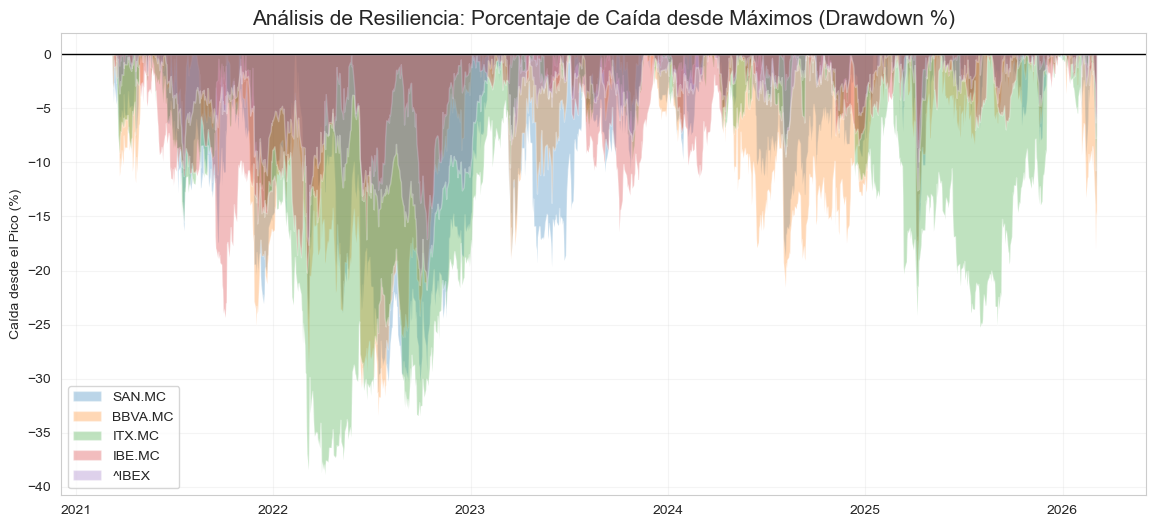

Ranking de Máxima Caída Histórica (MDD):
ITX.MC    -38.847577
BBVA.MC   -33.385176
SAN.MC    -31.608628
IBE.MC    -24.339973
^IBEX     -21.764657
dtype: float64


In [12]:
# Seleccionamos los 5 activos con más peso o interés
activos_resiliencia = ['SAN.MC', 'BBVA.MC', 'ITX.MC', 'IBE.MC', '^IBEX']

# Cálculo del Drawdown
prev_peaks = df_precios[activos_resiliencia].cummax()
drawdowns = (df_precios[activos_resiliencia] / prev_peaks) - 1


# Visualización de la "Profundidad de las Caídas"
plt.figure(figsize=(14, 6))
for activo in activos_resiliencia:
    plt.fill_between(drawdowns.index, drawdowns[activo]*100, label=activo, alpha=0.3)
plt.title('Análisis de Resiliencia: Porcentaje de Caída desde Máximos (Drawdown %)', fontsize=15)
plt.ylabel('Caída desde el Pico (%)')
plt.axhline(0, color='black', lw=1)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)
plt.show()
# Ranking de las caidas más grandes


mdd_ranking = drawdowns.min() * 100
print("Ranking de Máxima Caída Histórica (MDD):")
print(mdd_ranking.sort_values())

### Conclusiones del Análisis de Resiliencia (MDD):

- Mitigación del Riesgo Sistémico: El benchmark (^IBEX) presenta el menor Drawdown del grupo (-21.7%), validando la diversificación del índice como herramienta de protección frente a la volatilidad individual.
- Vulnerabilidad de los Líderes Sectoriales: Inditex (ITX.MC) registra la mayor caída máxima (-38.8%), evidenciando que el liderazgo de mercado no exime de episodios de alta volatilidad y riesgo de capital.
- Perfil Defensivo de las Utilities: Iberdrola (IBE.MC) se consolida como el activo individual más resiliente, manteniendo caídas significativamente menores que sus homólogos bancarios o de consumo.
- Correlación de Pérdidas: La proximidad en los indicadores de MDD de Santander y BBVA subraya la falta de diversificación real al concentrar inversiones en el sector bancario nacional.